# Train model

In [5]:
import os
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import hayai_util

portfolio_id = 'model'

context = hayai_util.create_context(portfolio_id)

## Step 1: build the dataset

In [6]:
filename = os.path.join(context['portfolio_dir'], hayai_util.FILE_FEATURES)
df = pd.read_parquet(filename)
# unisci le righe di tutti i dataframe in uno solo
df = df.dropna()
df.shape

(380252, 41)

## EDA

In [7]:
df.describe()

,AUDUSD,BZ,EURUSD,GBPUSD,GC,NZDUSD,USDCAD,USDCHF,USDJPY,^DJI,...,target,time_since_high,trend_50,vol_10,vol_20,vol_ratio,vol_regime,volume_shock,volume_zscore,zscore_20
count,380252.000000,380252.000000,380252.000000,380252.000000,380252.000000,380252.000000,380252.000000,380252.000000,380252.000000,380252.000000,...,380252.000000,380252.000000,380252.000000,380252.000000,380252.000000,380252.000000,380252.000000,380252.000000,380252.000000,380252.000000
mean,0.656723,75.831656,1.106448,1.292542,2854.215984,0.596558,1.374784,0.857271,149.480161,41025.103398,...,0.047275,437.706939,0.015120,0.042171,0.049564,0.872074,0.936533,1.010590,0.030608,0.110988
std,0.019162,8.865118,0.043375,0.041693,900.107071,0.018119,0.028899,0.043871,5.742809,4720.279916,...,1.261935,355.528252,0.113606,0.031947,0.033886,0.274392,0.365577,0.512748,1.034509,1.291897
min,0.595529,58.919998,1.024443,1.207846,1816.599976,0.551849,1.311250,0.763200,133.464996,32417.589844,...,-3.000000,0.000000,-0.319040,0.005043,0.006243,0.258232,0.306464,0.278823,-1.561031,-2.618330
25%,0.644990,68.589996,1.076670,1.262148,2034.000000,0.584300,1.356420,0.808130,145.613007,37753.308594,...,-0.657431,75.000000,-0.046471,0.020853,0.026550,0.669970,0.671990,0.693523,-0.643500,-0.947986
50%,0.655680,75.580002,1.092777,1.281263,2626.500000,0.597011,1.370210,0.872490,149.304993,41317.429688,...,0.057100,429.000000,0.010371,0.032950,0.040177,0.889516,0.879573,0.892214,-0.240874,0.173103
75%,0.667300,82.400002,1.152804,1.332747,3347.699951,0.610381,1.388460,0.895200,154.335999,44565.070312,...,0.768215,722.000000,0.069785,0.052915,0.062155,1.089167,1.136884,1.171391,0.424975,1.166865
max,0.712921,112.190002,1.201764,1.382533,5318.399902,0.639190,1.471700,0.920970,161.606995,50188.140625,...,3.000000,1250.000000,0.398757,0.186638,0.197655,1.371211,2.027240,3.414544,3.672545,2.697583


In [8]:
df = df.drop(columns=['date', 'symbol'])
df.info()

<class 'pandas.DataFrame'>
Index: 380252 entries, 472 to 619113
Data columns (total 39 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AUDUSD                 380252 non-null  float64
 1   BZ                     380252 non-null  float64
 2   EURUSD                 380252 non-null  float64
 3   GBPUSD                 380252 non-null  float64
 4   GC                     380252 non-null  float64
 5   NZDUSD                 380252 non-null  float64
 6   USDCAD                 380252 non-null  float64
 7   USDCHF                 380252 non-null  float64
 8   USDJPY                 380252 non-null  float64
 9   ^DJI                   380252 non-null  float64
 10  ^GSPC                  380252 non-null  float64
 11  ^IXIC                  380252 non-null  float64
 12  ^RUT                   380252 non-null  float64
 13  ^VIX1D                 380252 non-null  float64
 14  close_range            380252 non-null  float64
 1

In [9]:
# raise an error if there are any missing values
if df.isnull().values.any():
    raise ValueError("There are missing values in the dataframe")

## Target analysis

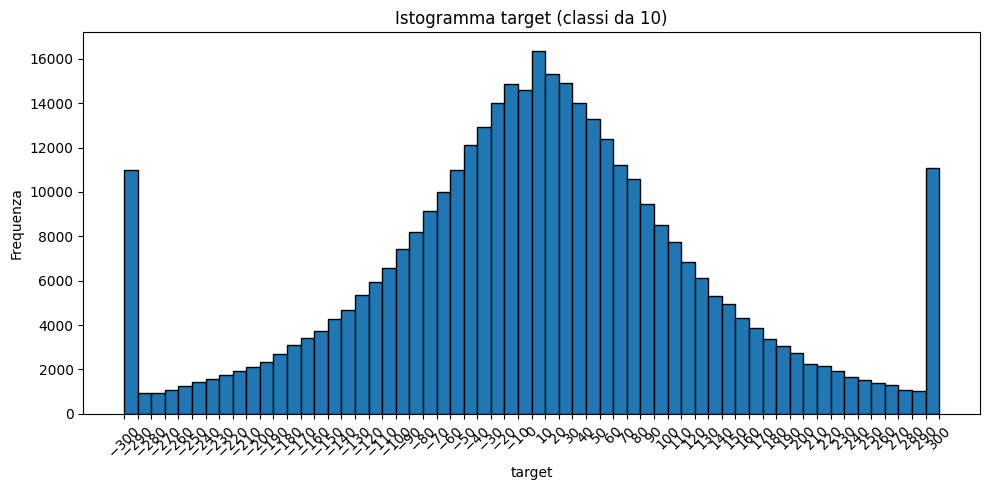

In [10]:
# Istogramma del target con classi (ampiezza) di 50
target_values = df['target']
target_values = target_values * 100
bin_start = math.floor(target_values.min() / 10) * 10
bin_end = math.ceil(target_values.max() / 10) * 10
bins = list(range(int(bin_start), int(bin_end) + 10, 10))

plt.figure(figsize=(10, 5))
plt.hist(target_values, bins=bins, edgecolor='black')
plt.title("Istogramma target (classi da 10)")
plt.xlabel("target")
plt.ylabel("Frequenza")
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()

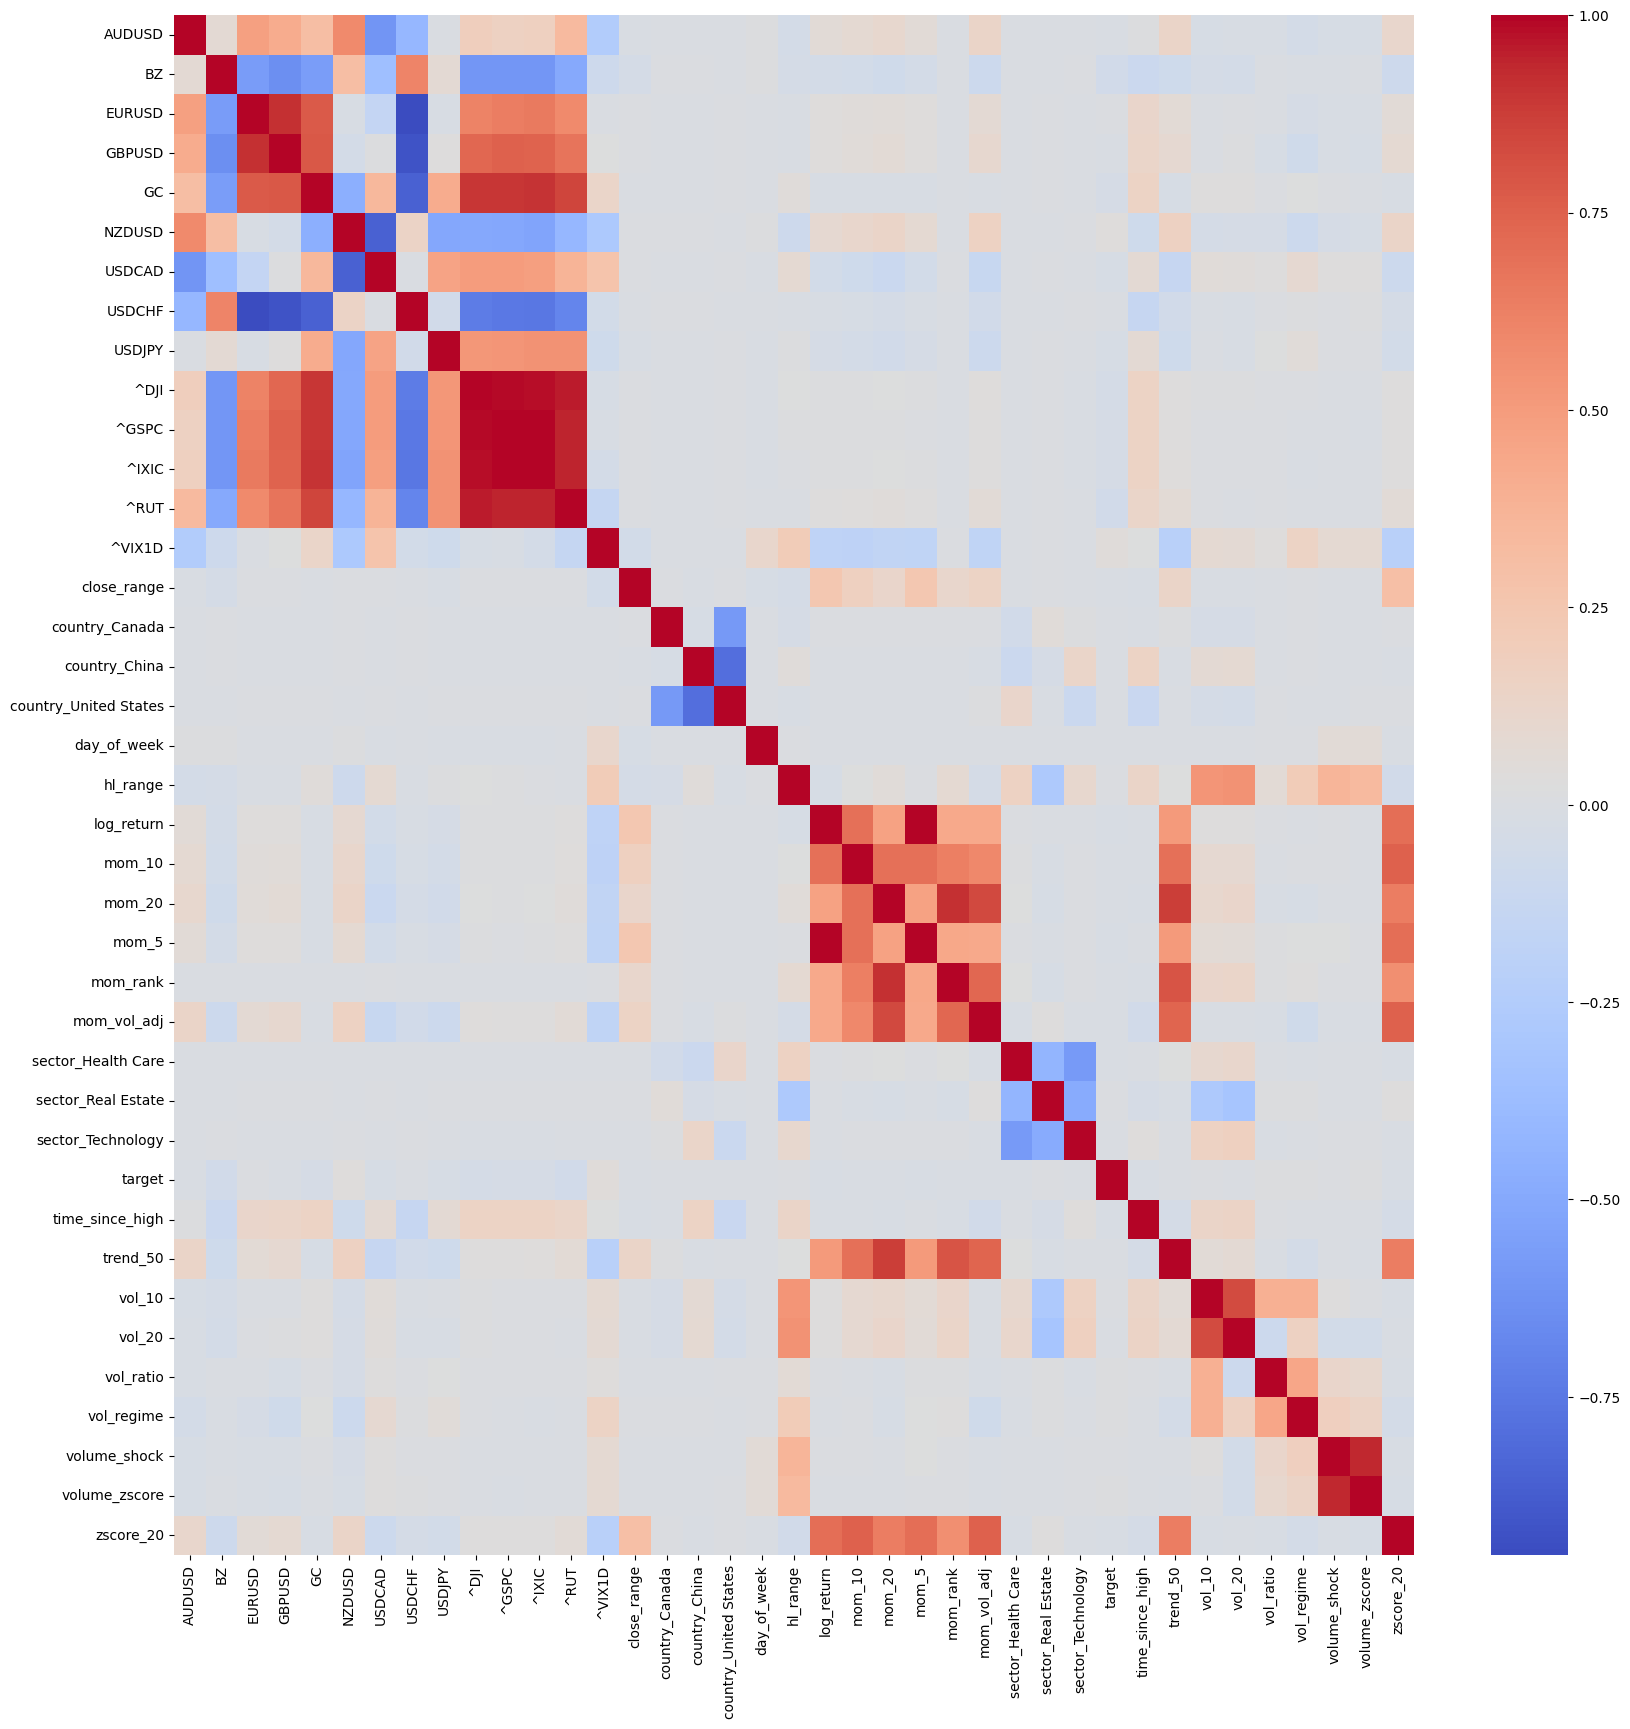

In [11]:
# display the correlation map using seaborn
plt.figure(figsize=(20, 20))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.show()

## Normalize

In [12]:
maxs = df.max()
mins = df.min()
df = (df - mins) / (maxs - mins)
label_min = mins['target']
label_max = maxs['target']
hayai_util.save_normalization_params(label_min, label_max)
maxs.index.name = "col"
maxs.name = "value"
maxs.to_csv(os.path.join(context['portfolio_dir'], "maxs.csv"), index=True)
mins.index.name = "col"
mins.name = "value"
mins.to_csv(os.path.join(context['portfolio_dir'], "mins.csv"), index=True)

## Model building

In [13]:
labels = df['target'].values
df = df.drop(columns=['target'])
data = df.values


In [14]:
from keras.models import Sequential
from keras.layers import Input, Dense,Conv1D,Conv2D,Flatten,MaxPool2D,BatchNormalization,MaxPooling1D
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
print("Labels Shape: %s" % (labels.shape,))
print("Data Shape: %s" % (data.shape,))
X, X_test, Y, Y_test = train_test_split(data, labels, test_size=0.2, random_state=1,shuffle=True)
print("Train Data Shape: %s" % (X.shape,))
print("Train Labels Shape: %s" % (Y.shape,))
print("Test Data Shape: %s" % (X_test.shape,))
print("Test Labels Shape: %s" % (Y_test.shape,))

Labels Shape: (380252,)
Data Shape: (380252, 38)
Train Data Shape: (304201, 38)
Train Labels Shape: (304201,)
Test Data Shape: (76051, 38)
Test Labels Shape: (76051,)


In [15]:
n_row = data.shape[1]
channels = 1 # non ci sono colori, il channel è 1 (usato solo in Conv2D)
batch_size = 64

model = Sequential()
model.add(Input(shape=(n_row,), name='input_layer'))
model.add(Dense(100, activation='relu',name='layerDense1'))
model.add(Dense(80, activation='relu',name='layerDense2'))
model.add(Dense(20, activation='relu',name='layerDense3'))
model.add(Dense(1,activation='sigmoid',name='output_layer'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layerDense1 (Dense)             │ (None, 100)            │         3,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense2 (Dense)             │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense3 (Dense)             │ (None, 20)             │         1,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,621 (53.21 KB)

 Trainable params: 13,621 (53.21 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# questa è la funzione di costo
optimizer = Adam(learning_rate=context['learning_rate'])
model.compile(loss='mean_squared_error', optimizer=optimizer)
#model.compile(loss='mean_squared_error', optimizer='SGD')

# questo è il training
model.fit(
    X,
    Y,
    epochs=context['epochs'],
    shuffle=True,
    verbose=2,
    batch_size=context['batch_size'],
    validation_split=context['validation_split']
)
# il modello è pronto, applichiamo il modello al dataset di test

results = model.evaluate(X_test, Y_test, verbose=2,)
print("Test loss: %f" % results)
filename = os.path.join(context['portfolio_dir'], 'model_summary.txt')
with open(filename, 'w',encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
model.save(os.path.join(context['portfolio_dir'], 'model.keras'))
print("Model saved to: %s" % os.path.join(context['portfolio_dir'], 'model.keras'))

Epoch 1/30
1902/1902 - 4s - 2ms/step - loss: 0.0424 - val_loss: 0.0409
Epoch 2/30
1902/1902 - 3s - 1ms/step - loss: 0.0405 - val_loss: 0.0398
Epoch 3/30
1902/1902 - 3s - 2ms/step - loss: 0.0397 - val_loss: 0.0391
Epoch 4/30
1902/1902 - 3s - 1ms/step - loss: 0.0390 - val_loss: 0.0384
Epoch 5/30
1902/1902 - 3s - 1ms/step - loss: 0.0383 - val_loss: 0.0379
Epoch 6/30
1902/1902 - 3s - 1ms/step - loss: 0.0378 - val_loss: 0.0376
Epoch 7/30
1902/1902 - 3s - 1ms/step - loss: 0.0374 - val_loss: 0.0377
Epoch 8/30
1902/1902 - 2s - 1ms/step - loss: 0.0370 - val_loss: 0.0372
Epoch 9/30
1902/1902 - 2s - 1ms/step - loss: 0.0367 - val_loss: 0.0370
Epoch 10/30
1902/1902 - 2s - 1ms/step - loss: 0.0364 - val_loss: 0.0371
Epoch 11/30
1902/1902 - 2s - 1ms/step - loss: 0.0362 - val_loss: 0.0367
Epoch 12/30
1902/1902 - 3s - 1ms/step - loss: 0.0360 - val_loss: 0.0364
Epoch 13/30
1902/1902 - 2s - 1ms/step - loss: 0.0358 - val_loss: 0.0360
Epoch 14/30
1902/1902 - 2s - 1ms/step - loss: 0.0355 - val_loss: 0.0361
E

Model saved to: data\model\model.keras


In [17]:
tp = 0
tn = 0
fp = 0
fn = 0
#denormalize labels
labels = Y_test * (label_max - label_min) + label_min
predictions = model.predict(X_test, verbose=0)
print("min and max of predictions ", predictions.min(), predictions.max())
errors = []
for i in range(len(X_test)):
    p = predictions[i][0]
    label = labels[i]
    p = p * (label_max - label_min) + label_min # denormalize prediction
    if i < 30:
        print(f"Label: {label:.4f}, Prediction: {p:.4f}")
    errors.append((label - p))
    if label > 0 and p > 0:
        tp += 1
    elif label <= 0 and p <= 0:
        tn += 1
    elif label <= 0 and p > 0:
        fp += 1
    elif label > 0 and p <= 0:
        fn += 1
eqm = math.sqrt(sum([e**2 for e in errors])/len(errors))
print(f"Mean Squared Error: {eqm:.4f}")
print("True Positives: %d, True Negatives: %d, False Positives: %d, False Negatives: %d" % (tp, tn, fp, fn))
print("positive labels: %d, negative labels: %d" % (sum(labels > 0), sum(labels <= 0)))
print("Sum true",tp+tn, "Sum false",fp+fn)
print("Precision: %.4f" % (tp / (tp + fp) if (tp + fp) > 0 else 0))
print("Recall: %.4f" % (tp / (tp + fn) if (tp + fn) > 0 else 0))
print("Accuracy: %.4f" % ((tp + tn) / len(X_test) if len(X_test) > 0 else 0))

pred_denorm = predictions.flatten() * (label_max - label_min) + label_min
corr = pd.Series(labels).corr(pd.Series(pred_denorm))
print(f"Correlation (labels vs predictions): {corr:.4f}")

min and max of predictions  0.030987626 0.9463097
Label: -2.1334, Prediction: 0.3740
Label: 1.6751, Prediction: 0.2717
Label: 0.1813, Prediction: 0.4001
Label: 1.2878, Prediction: 0.3591
Label: -0.9056, Prediction: 0.1297
Label: -0.2078, Prediction: -0.0780
Label: 3.0000, Prediction: 1.0003
Label: 0.1072, Prediction: 0.6303
Label: 0.7165, Prediction: 0.6431
Label: -1.2854, Prediction: -0.2922
Label: 0.9334, Prediction: 0.1265
Label: -0.4196, Prediction: -0.7698
Label: -0.8246, Prediction: -0.5976
Label: -1.0389, Prediction: -0.8177
Label: -0.6574, Prediction: 0.1040
Label: 0.3602, Prediction: -0.0114
Label: 0.8835, Prediction: -0.2001
Label: 1.7055, Prediction: 0.5310
Label: -0.2246, Prediction: -0.0091
Label: -0.2917, Prediction: -0.7556
Label: 0.3397, Prediction: -0.0183
Label: 1.4845, Prediction: 0.5961
Label: 2.5195, Prediction: 1.5746
Label: -0.3656, Prediction: 0.2731
Label: -0.1036, Prediction: 0.2394
Label: 0.9523, Prediction: 0.3439
Label: -0.4335, Prediction: -0.7791
Label: -